In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv


In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn nltk scipy -q

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from scipy.stats import loguniform, randint

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)

print("Done.")

Done.


In [4]:
URL = "/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv"
df = pd.read_csv(URL)
print(f"Shape: {df.shape}")
df.head()

Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
print(df.info())
print("\n" + "="*50)
print(df.describe())
print("\n" + "="*50)
print("\nClass distribution:")
print(df['class'].value_counts())
print("\nNull values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None

         Unnamed: 0         count   hate_speech  offensive_language  \
count  24783.000000  24783.000000  24783.000000        24783.000000   
mean   12681.192027      3.243473      0.280515            2.413711   
std     7299.553863      0.883060      0.631851            1.399459   
min        0.000000      3.000000      0.000000            0.000000   
25%     6372.500000      3.000000      0.000000  

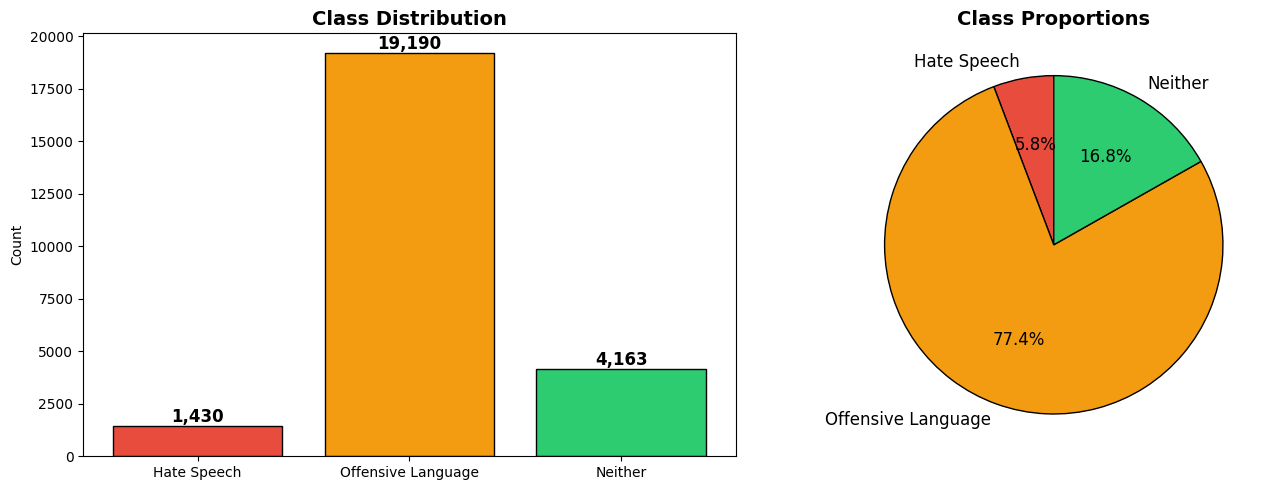

In [6]:
label_map = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['class'].value_counts().sort_index()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar([label_map[i] for i in counts.index], counts.values, color=colors, edgecolor='black')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=[label_map[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

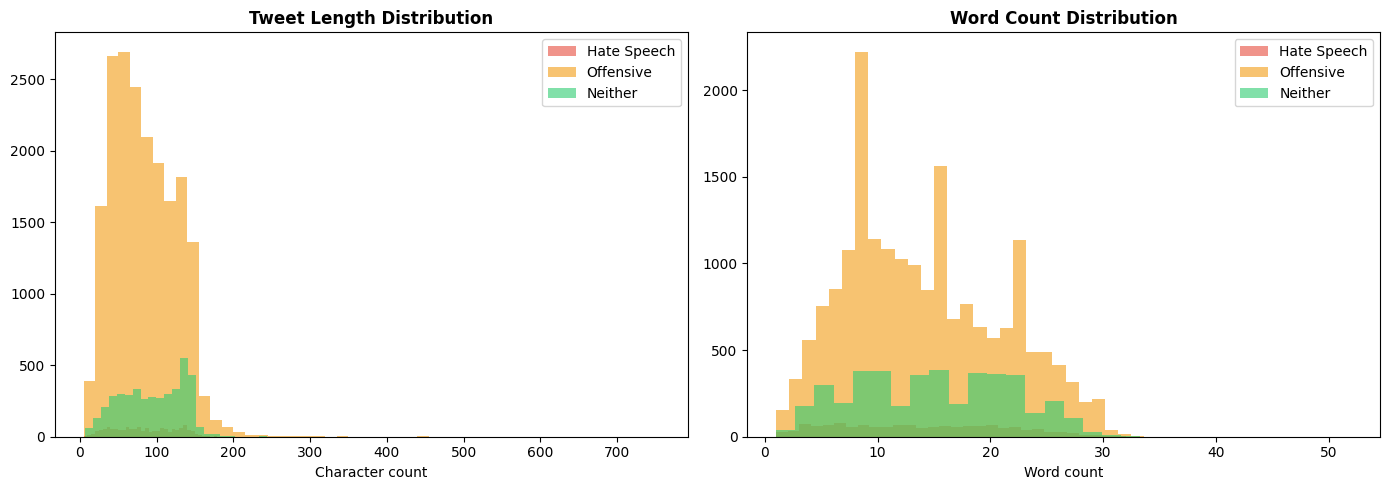

In [7]:
df['tweet_length'] = df['tweet'].str.len()
df['word_count'] = df['tweet'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cls, color, label in [(0, '#e74c3c', 'Hate Speech'),
                           (1, '#f39c12', 'Offensive'),
                           (2, '#2ecc71', 'Neither')]:
    subset = df[df['class'] == cls]
    axes[0].hist(subset['tweet_length'], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['word_count'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Tweet Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character count')
axes[0].legend()
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Correlations between numeric variables
num_cols = [c for c in ['count', 'hate_speech', 'offensive_language', 'neither', 'tweet_length', 'word_count'] if c in df.columns]
corr_df = df[num_cols + ['class']].copy()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (Numeric Features + Class)', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'rt\s+', '', text)
    text = re.sub(r'&amp;|&lt;|&gt;', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_tweet'] = df['tweet'].apply(preprocess_text)

df = df[df['clean_tweet'].str.len() > 0].reset_index(drop=True)

print(f"Dataset after cleaning: {df.shape[0]} rows")
print("\nBefore - After examples:")
for i in [0, 100, 500]:
    print(f"  Original:  {df['tweet'].iloc[i][:80]}...")
    print(f"  Cleaned:   {df['clean_tweet'].iloc[i][:80]}")
    print()

Dataset after cleaning: 24780 rows

Before - After examples:
  Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your h...
  Cleaned:   woman shouldnt complain cleaning house man always take trash

  Original:  "@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjm...
  Cleaned:   lmaooooooooooo nigga bitch want like depressing shitfoh

  Original:  "I'm probably your main bitch chocolate dipped cinnamon apple"...
  Cleaned:   probably main bitch chocolate dipped cinnamon apple



In [ ]:
X = df['clean_tweet']
y = df['class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Test: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

Train: (19824, 21879)
Test:  (4956, 21879)
Vocabulary size: 21,879


## Algorithmes retenus et justification
Nous comparons 4 algorithmes de classification, chacun avec un réglage d'hyperparamètres via `RandomizedSearchCV` :

1. **Régression logistique** : baseline robuste pour le texte TF-IDF; interprétable et efficace sur grande dimension.
2. **SVM linéaire** : très performant sur les représentations creuses du NLP.
3. **Naive Bayes multinomial** : modèle rapide, adapté aux fréquences de mots et aux features TF-IDF.
4. **Random Forest** : modèle non-linéaire pour capter des interactions entre features.

Chaque modèle est ajusté sur l'entraînement puis comparé sur validation avant test final.

In [ ]:
search_spaces = {
    "Logistic Regression": {
        'estimator': LogisticRegression(solver='saga', max_iter=1500, random_state=42, n_jobs=-1),
        'params': {
            'C': loguniform(1e-2, 20),
            'penalty': ['l1', 'l2']
        }
    },
    "Linear SVM": {
        'estimator': LinearSVC(random_state=42),
        'params': {
            'C': loguniform(1e-3, 30),
            'max_iter': [2000, 3000, 5000]
        }
    },
    "Multinomial NB": {
        'estimator': MultinomialNB(),
        'params': {
            'alpha': loguniform(1e-3, 2)
        }
    },
    "Random Forest": {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': randint(150, 500),
            'max_depth': [None, 20, 40, 60],
            'min_samples_split': randint(2, 10),
            'min_samples_leaf': randint(1, 5)
        }
    }
}

best_models = {}
results = []

print(f"{'Model':<22} {'Val Acc':>10} {'Val Macro-F1':>14} {'Best Params':>20}")
print("=" * 90)

for name, spec in search_spaces.items():
    search = RandomizedSearchCV(
        estimator=spec['estimator'],
        param_distributions=spec['params'],
        n_iter=10,
        scoring='f1_macro',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train_tfidf, y_train)

    best_model = search.best_estimator_
    val_pred = best_model.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average='macro')

    best_models[name] = best_model
    results.append({
        'Model': name,
        'Val Accuracy': val_acc,
        'Val Macro F1': val_f1,
        'Best Params': search.best_params_
    })

    print(f"{name:<22} {val_acc:>10.4f} {val_f1:>14.4f} {str(search.best_params_)[:20]:>20}")

print("\nHyperparameter tuning complete.")

Model                       Accuracy   Macro F1       Time
Logistic Regression          0.8989    0.7096      0.4s
Linear SVM                   0.8951    0.7060      0.2s
Multinomial NB               0.8610    0.5888      0.0s
Random Forest                0.8989    0.6725     36.8s
Gradient Boosting            0.9033    0.7234    124.7s
XGBoost                      0.9044    0.7209     46.5s
LightGBM                     0.8904    0.6892     15.2s

 All models trained.


In [ ]:
res_df = pd.DataFrame(results).sort_values('Val Macro F1', ascending=False).reset_index(drop=True)

print("\n" + "=" * 95)
print("                     MODEL RANKING ON VALIDATION SET")
print("=" * 95)
print(res_df[['Model', 'Val Accuracy', 'Val Macro F1']].to_string(index=False))
print("=" * 95)

best_model_name = res_df.iloc[0]['Model']
best_model = best_models[best_model_name]

print(f"\nBest model selected from validation: {best_model_name}")
print(f"Best hyperparameters: {res_df.iloc[0]['Best Params']}")

Training Stacking Ensemble (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Stacking Ensemble - Accuracy: 0.9082  |  Macro F1: 0.7219  |  Time: 326.5s


In [ ]:
# Test-set evaluation for each tuned model
test_results = []
pred_store = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_tfidf)
    pred_store[name] = y_pred

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    test_results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision (macro)': precision,
        'Test Recall (macro)': recall,
        'Test F1 (macro)': f1
    })

test_df_metrics = pd.DataFrame(test_results).sort_values('Test F1 (macro)', ascending=False).reset_index(drop=True)
print(test_df_metrics.to_string(index=False))


              FINAL MODEL RANKINGS
              Model  Accuracy  Macro F1   Time (s)
  Stacking Ensemble  0.908192  0.721851 326.497511
            XGBoost  0.904358  0.720866  46.535695
  Gradient Boosting  0.903349  0.723402 124.710942
Logistic Regression  0.898910  0.709633   0.427423
      Random Forest  0.898910  0.672456  36.758660
         Linear SVM  0.895077  0.706038   0.177226
           LightGBM  0.890436  0.689182  15.232928
     Multinomial NB  0.860977  0.588833   0.007872

 BEST MODEL: Stacking Ensemble — Accuracy: 0.9082 (90.82%)


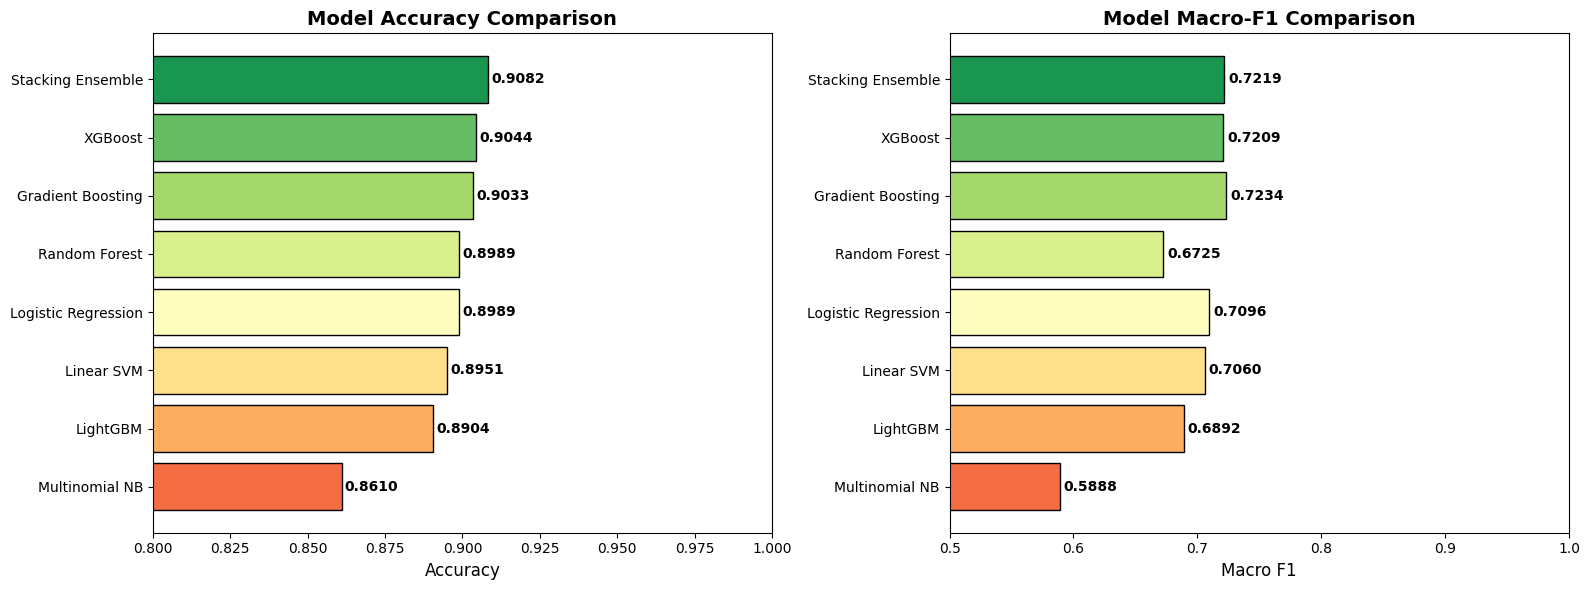

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sorted_res = test_df_metrics.sort_values('Test Accuracy', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_res)))

axes[0].barh(sorted_res['Model'], sorted_res['Test Accuracy'], color=colors, edgecolor='black')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.0, 1.0)
for i, acc in enumerate(sorted_res['Test Accuracy']):
    axes[0].text(min(acc + 0.01, 0.98), i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

axes[1].barh(sorted_res['Model'], sorted_res['Test F1 (macro)'], color=colors, edgecolor='black')
axes[1].set_xlabel('Macro F1', fontsize=12)
axes[1].set_title('Test Macro-F1 Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.0, 1.0)
for i, f1 in enumerate(sorted_res['Test F1 (macro)']):
    axes[1].text(min(f1 + 0.01, 0.98), i, f'{f1:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
target_names = ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']

for name in test_df_metrics['Model']:
    print(f"\nClassification Report - {name}")
    print("=" * 70)
    print(classification_report(y_test, pred_store[name], target_names=target_names, zero_division=0))

Classification Report — Stacking Ensemble
                 precision    recall  f1-score   support

Hate Speech (0)       0.55      0.25      0.34       286
  Offensive (1)       0.93      0.96      0.95      3838
    Neither (2)       0.85      0.91      0.88       832

       accuracy                           0.91      4956
      macro avg       0.78      0.71      0.72      4956
   weighted avg       0.90      0.91      0.90      4956



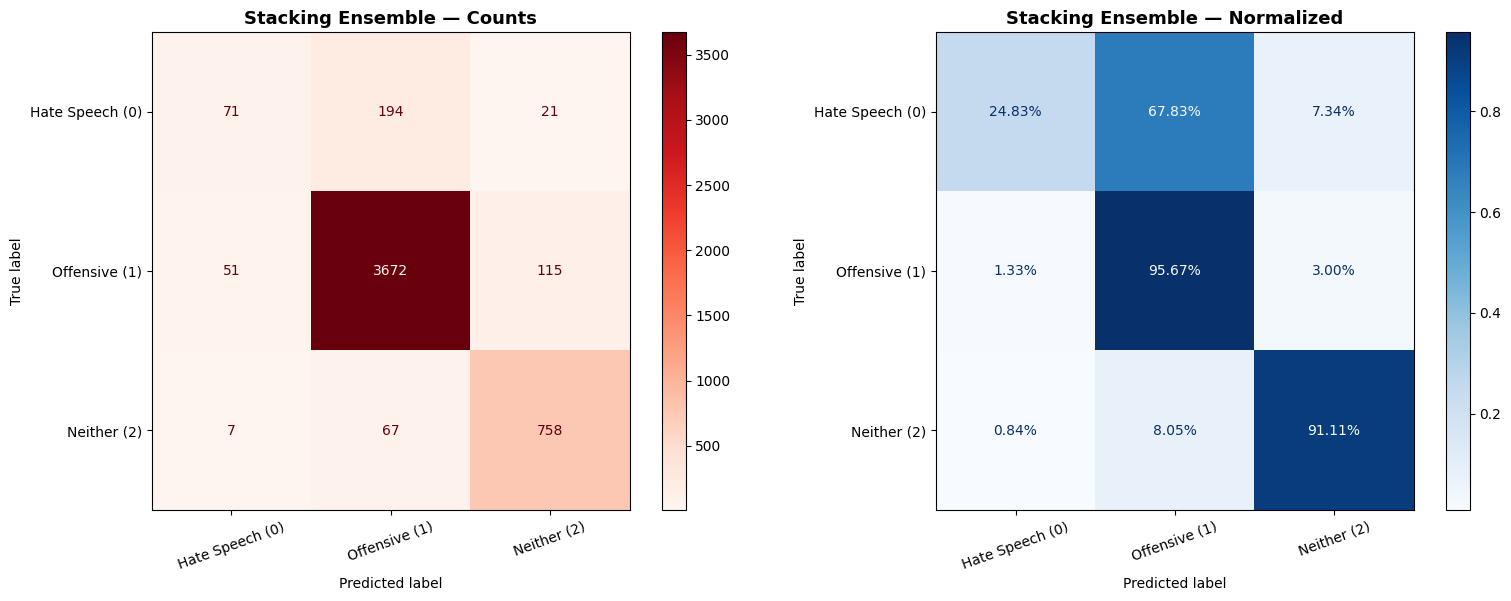

In [ ]:
models_for_cm = list(test_df_metrics['Model'])
n_models = len(models_for_cm)
fig, axes = plt.subplots(2, n_models, figsize=(4 * n_models, 8))

if n_models == 1:
    axes = np.array(axes).reshape(2, 1)

for i, name in enumerate(models_for_cm):
    y_pred = pred_store[name]

    cm = confusion_matrix(y_test, y_pred)
    disp_counts = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp_counts.plot(ax=axes[0, i], cmap='Reds', values_format='d', colorbar=False)
    axes[0, i].set_title(f'{name}\nCounts', fontsize=11, fontweight='bold')
    axes[0, i].tick_params(axis='x', rotation=20)

    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=target_names)
    disp_norm.plot(ax=axes[1, i], cmap='Blues', values_format='.2f', colorbar=False)
    axes[1, i].set_title(f'{name}\nNormalized', fontsize=11, fontweight='bold')
    axes[1, i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# 5-fold cross-validation for each tuned model
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
X_trainval_tfidf = tfidf.transform(X_trainval)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

print("5-Fold Stratified Cross-Validation (Accuracy & Macro-F1)")
print("=" * 70)

for name, model in best_models.items():
    acc_scores = cross_val_score(model, X_trainval_tfidf, y_trainval, cv=skf, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(model, X_trainval_tfidf, y_trainval, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'CV Accuracy Mean': acc_scores.mean(),
        'CV Accuracy Std': acc_scores.std(),
        'CV F1 Mean': f1_scores.mean(),
        'CV F1 Std': f1_scores.std()
    })
    print(f"{name:<22} | Acc: {acc_scores.mean():.4f} +/- {acc_scores.std():.4f} | F1: {f1_scores.mean():.4f} +/- {f1_scores.std():.4f}")

cv_df = pd.DataFrame(cv_rows).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)

5-Fold Stratified Cross-Validation
XGBoost                   0.9023 ± 0.0036  (folds: [0.8997 0.8967 0.9054 0.9064 0.9036])
Logistic Regression       0.8988 ± 0.0031  (folds: [0.8961 0.8949 0.9029 0.8983 0.9017])

Cross-validation complete.


In [ ]:
# Learning curve for the selected final model
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_trainval_tfidf,
    y=y_trainval,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
 )

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train F1 (macro)')
plt.plot(train_sizes, val_scores.mean(axis=1), marker='s', label='Validation F1 (macro)')
plt.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.2
 )
plt.title(f'Learning Curve - {best_model_name}', fontweight='bold')
plt.xlabel('Training set size')
plt.ylabel('Macro F1')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance / influential terms
feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(best_model, 'coef_'):
    coef = best_model.coef_
    importance = np.mean(np.abs(coef), axis=0)
    top_idx = np.argsort(importance)[-20:]
    top_values = importance[top_idx]
    top_labels = feature_names[top_idx]
    title = f'Top 20 Influential Features - {best_model_name} (|coef| mean)'
elif hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    top_idx = np.argsort(importance)[-20:]
    top_values = importance[top_idx]
    top_labels = feature_names[top_idx]
    title = f'Top 20 Feature Importances - {best_model_name}'
else:
    top_idx = np.array([], dtype=int)
    top_values = np.array([])
    top_labels = np.array([])
    title = f'Feature importance not available for {best_model_name}'

if len(top_idx) > 0:
    plt.figure(figsize=(9, 7))
    plt.barh(top_labels, top_values, color='#3498db', edgecolor='black')
    plt.title(title, fontweight='bold')
    plt.xlabel('Importance score')
    plt.tight_layout()
    plt.show()
else:
    print(title)

In [ ]:
best_preds = pred_store[best_model_name]

analysis_df = pd.DataFrame({
    'tweet': X_test.values,
    'true_label': y_test.values,
    'predicted': best_preds
})
analysis_df['correct'] = analysis_df['true_label'] == analysis_df['predicted']

misclassified = analysis_df[~analysis_df['correct']].copy()
misclassified['true_name'] = misclassified['true_label'].map(label_map)
misclassified['pred_name'] = misclassified['predicted'].map(label_map)

print(f"Final model analyzed: {best_model_name}")
print(f"Total test samples: {len(analysis_df):,}")
print(f"Misclassified: {len(misclassified):,} ({len(misclassified)/len(analysis_df)*100:.1f}%)")
print()

error_types = misclassified.groupby(['true_name', 'pred_name']).size().sort_values(ascending=False)
print("Most common error types:")
print(error_types.head(6).to_string())

print("\n--- Sample Misclassified Tweets ---")
for _, row in misclassified.head(5).iterrows():
    print(f"  True: {row['true_name']:<20} Pred: {row['pred_name']:<20}")
    print(f"  Tweet: {row['tweet'][:100]}...")
    print()

Total test samples: 4,956
Misclassified: 455 (9.2%)

Most common error types:
true_name           pred_name         
Hate Speech         Offensive Language    194
Offensive Language  Neither               115
Neither             Offensive Language     67
Offensive Language  Hate Speech            51
Hate Speech         Neither                21
Neither             Hate Speech             7

--- Sample Misclassified Tweets ---
  True: Hate Speech          Pred: Neither             
  Tweet: stupid teabagger restaurant making customer pay minimum wage fee...

  True: Hate Speech          Pred: Offensive Language  
  Tweet: dont fuck bitch nigga fuck nigga bitch...

  True: Offensive Language   Pred: Neither             
  Tweet: thus term redneck also creator mocked good youexcellent precept daughter...

  True: Offensive Language   Pred: Neither             
  Tweet: thats know lying getting pussytalking tasting like water fruit shittf...

  True: Hate Speech          Pred: Offensive La

In [ ]:
import pickle

# Refit the selected model on train+validation before final saving
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
X_trainval_tfidf = tfidf.fit_transform(X_trainval)
X_test_tfidf = tfidf.transform(X_test)

best_for_save = best_models[best_model_name]
best_for_save.fit(X_trainval_tfidf, y_trainval)

with open('hate_speech_model.pkl', 'wb') as f:
    pickle.dump({'model': best_for_save, 'tfidf': tfidf, 'label_map': label_map}, f)

print(f"Model saved to 'hate_speech_model.pkl' ({best_model_name})")
print(f"File size: {__import__('os').path.getsize('hate_speech_model.pkl') / 1e6:.1f} MB")

Model saved to 'hate_speech_model.pkl'
   File size: 1.4 MB


In [ ]:
def predict_hate_speech(texts, model=best_for_save, vectorizer=tfidf):
    if isinstance(texts, str):
        texts = [texts]

    cleaned = [preprocess_text(t) for t in texts]
    features = vectorizer.transform(cleaned)
    preds = model.predict(features)

    if hasattr(model, 'predict_proba'):
        probas = model.predict_proba(features)
    else:
        probas = None

    results = []
    for i, (text, pred) in enumerate(zip(texts, preds)):
        row = {
            'text': text[:80],
            'prediction': label_map[pred]
        }
        if probas is not None:
            row['confidence'] = f"{probas[i].max()*100:.1f}%"
            row['probabilities'] = {label_map[j]: f"{p:.3f}" for j, p in enumerate(probas[i])}
        results.append(row)
    return results

test_texts = [
    "I love spending time with my friends at the park",
    "This movie is absolutely terrible, worst thing ever made",
    "You're all stupid idiots who deserve nothing",
    "Great game today! What a performance by the team",
    "I hate mondays so much, worst day of the week",
]

print("Quick Inference Demo")
print("=" * 70)
for r in predict_hate_speech(test_texts):
    print(f"Text: {r['text']}")
    print(f"-> {r['prediction']}")
    if 'confidence' in r:
        print(f"   Confidence: {r['confidence']}")
        print(f"   Probabilities: {r['probabilities']}")
    print()

Quick Inference Demo
  Text: I love spending time with my friends at the park
  → Neither (70.0%)
    Probabilities: {'Hate Speech': '0.036', 'Offensive Language': '0.264', 'Neither': '0.700'}

  Text: This movie is absolutely terrible, worst thing ever made
  → Neither (75.7%)
    Probabilities: {'Hate Speech': '0.081', 'Offensive Language': '0.162', 'Neither': '0.757'}

  Text: You're all stupid idiots who deserve nothing
  → Offensive Language (54.5%)
    Probabilities: {'Hate Speech': '0.359', 'Offensive Language': '0.545', 'Neither': '0.096'}

  Text: Great game today! What a performance by the team
  → Neither (96.8%)
    Probabilities: {'Hate Speech': '0.002', 'Offensive Language': '0.030', 'Neither': '0.968'}

  Text: I hate mondays so much, worst day of the week
  → Neither (85.5%)
    Probabilities: {'Hate Speech': '0.024', 'Offensive Language': '0.121', 'Neither': '0.855'}



In [ ]:
import os
from datetime import datetime

output_dir = '../Outputs'
os.makedirs(output_dir, exist_ok=True)

# 1. Sauvegarde des DataFrames résultats
res_df[['Model', 'Val Accuracy', 'Val Macro F1']].to_csv(f'{output_dir}/validation_results.csv', index=False)
test_df_metrics.to_csv(f'{output_dir}/test_results.csv', index=False)
cv_df.to_csv(f'{output_dir}/cross_validation_results.csv', index=False)

# 2. Sauvegarde des diagrammes
# Diagramme: Comparaison performance
fig_perf, axes = plt.subplots(1, 2, figsize=(16, 6))
sorted_res = test_df_metrics.sort_values('Test Accuracy', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_res)))

axes[0].barh(sorted_res['Model'], sorted_res['Test Accuracy'], color=colors, edgecolor='black')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.0, 1.0)
for i, acc in enumerate(sorted_res['Test Accuracy']):
    axes[0].text(min(acc + 0.01, 0.98), i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

axes[1].barh(sorted_res['Model'], sorted_res['Test F1 (macro)'], color=colors, edgecolor='black')
axes[1].set_xlabel('Macro F1', fontsize=12)
axes[1].set_title('Test Macro-F1 Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.0, 1.0)
for i, f1 in enumerate(sorted_res['Test F1 (macro)']):
    axes[1].text(min(f1 + 0.01, 0.98), i, f'{f1:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_perf.savefig(f'{output_dir}/01_model_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# Diagrammes: Matrices de confusion
models_for_cm = list(test_df_metrics['Model'])
n_models = len(models_for_cm)
target_names = ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']

fig_cm, axes = plt.subplots(2, n_models, figsize=(4 * n_models, 8))
if n_models == 1:
    axes = np.array(axes).reshape(2, 1)

for i, name in enumerate(models_for_cm):
    y_pred = pred_store[name]

    cm = confusion_matrix(y_test, y_pred)
    disp_counts = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp_counts.plot(ax=axes[0, i], cmap='Reds', values_format='d', colorbar=False)
    axes[0, i].set_title(f'{name}\nCounts', fontsize=11, fontweight='bold')
    axes[0, i].tick_params(axis='x', rotation=20)

    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=target_names)
    disp_norm.plot(ax=axes[1, i], cmap='Blues', values_format='.2f', colorbar=False)
    axes[1, i].set_title(f'{name}\nNormalized', fontsize=11, fontweight='bold')
    axes[1, i].tick_params(axis='x', rotation=20)

plt.tight_layout()
fig_cm.savefig(f'{output_dir}/02_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.close()

# Diagramme: Courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_trainval_tfidf,
    y=y_trainval,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

fig_lc, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train F1 (macro)', linewidth=2)
ax.plot(train_sizes, val_scores.mean(axis=1), marker='s', label='Validation F1 (macro)', linewidth=2)
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.2
)
ax.set_title(f'Learning Curve - {best_model_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Training set size')
ax.set_ylabel('Macro F1')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
fig_lc.savefig(f'{output_dir}/03_learning_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# Diagramme: Feature importance
feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(best_model, 'coef_'):
    coef = best_model.coef_
    importance = np.mean(np.abs(coef), axis=0)
    top_idx = np.argsort(importance)[-20:]
    top_values = importance[top_idx]
    top_labels = feature_names[top_idx]
    title = f'Top 20 Influential Features - {best_model_name}'
    fig_fi, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_labels, top_values, color='#3498db', edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    fig_fi.savefig(f'{output_dir}/04_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.close()
elif hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    top_idx = np.argsort(importance)[-20:]
    top_values = importance[top_idx]
    top_labels = feature_names[top_idx]
    title = f'Top 20 Feature Importances - {best_model_name}'
    fig_fi, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_labels, top_values, color='#3498db', edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance score')
    plt.tight_layout()
    fig_fi.savefig(f'{output_dir}/04_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.close()

# 3. Création d'un rapport résumé
report_path = f'{output_dir}/summary_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f"{'='*80}\n")
    f.write(f"RAPPORT D'ANALYSE - MODELE HATE SPEECH DETECTION\n")
    f.write(f"Généré: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"{'='*80}\n\n")
    
    f.write(f"1. MODELE SELECTIONNE\n")
    f.write(f"{'-'*80}\n")
    f.write(f"Meilleur modèle (validation): {best_model_name}\n")
    f.write(f"Accuracy (test): {test_df_metrics.iloc[0]['Test Accuracy']:.4f}\n")
    f.write(f"Macro-F1 (test): {test_df_metrics.iloc[0]['Test F1 (macro)']:.4f}\n")
    f.write(f"Hyperparamètres: {res_df.iloc[0]['Best Params']}\n\n")
    
    f.write(f"2. RESULTATS PAR MODELE (SET TEST)\n")
    f.write(f"{'-'*80}\n")
    for idx, row in test_df_metrics.iterrows():
        f.write(f"\n{row['Model']}:\n")
        f.write(f"  - Accuracy: {row['Test Accuracy']:.4f}\n")
        f.write(f"  - Precision (macro): {row['Test Precision (macro)']:.4f}\n")
        f.write(f"  - Recall (macro): {row['Test Recall (macro)']:.4f}\n")
        f.write(f"  - F1 (macro): {row['Test F1 (macro)']:.4f}\n")
    
    f.write(f"\n3. VALIDATION CROISEE (5-FOLD)\n")
    f.write(f"{'-'*80}\n")
    for idx, row in cv_df.iterrows():
        f.write(f"{row['Model']}: Acc {row['CV Accuracy Mean']:.4f}±{row['CV Accuracy Std']:.4f} | F1 {row['CV F1 Mean']:.4f}±{row['CV F1 Std']:.4f}\n")
    
    f.write(f"\n4. DISTRIBUTON ENSEMBLE DE DONNEES\n")
    f.write(f"{'-'*80}\n")
    f.write(f"Taille train: {len(X_train):,}\n")
    f.write(f"Taille validation: {len(X_val):,}\n")
    f.write(f"Taille test: {len(X_test):,}\n")
    f.write(f"Vocabulaire TF-IDF: {len(tfidf.vocabulary_):,} terms\n\n")
    
    f.write(f"5. ANALYSE DES ERREURS (MODELE FINAL)\n")
    f.write(f"{'-'*80}\n")
    f.write(f"Total test: {len(analysis_df):,}\n")
    f.write(f"Mal classifiés: {len(misclassified):,} ({len(misclassified)/len(analysis_df)*100:.1f}%)\n\n")
    f.write(f"Types d'erreurs les plus courants:\n")
    for (true, pred), count in error_types.head(6).items():
        f.write(f"  {true:20} → {pred:20} : {count} occurrences\n")
    
    f.write(f"\n{'='*80}\n")
    f.write(f"Fichiers générés:\n")
    f.write(f"  - validation_results.csv\n")
    f.write(f"  - test_results.csv\n")
    f.write(f"  - cross_validation_results.csv\n")
    f.write(f"  - 01_model_comparison.png\n")
    f.write(f"  - 02_confusion_matrices.png\n")
    f.write(f"  - 03_learning_curve.png\n")
    f.write(f"  - 04_feature_importance.png\n")
    f.write(f"  - summary_report.txt\n")
    f.write(f"\n{'='*80}\n")

print(f"\n📊 Sauvegarde terminée!")
print(f"Dossier de sortie: {os.path.abspath(output_dir)}")
print(f"Fichiers générés: 4 diagrammes + 3 CSV + 1 rapport texte")